# ACDADA — Notebook 02: Threat Detection Agent

**Agent 1: Binary Intrusion Detection (Malicious vs Benign)**

This notebook implements:
1. Enhanced MLP-based network traffic classifier
2. Training with early stopping, cosine annealing LR, class weighting
3. Comprehensive evaluation (ROC-AUC, PR-AUC, Confusion Matrix)
4. Bootstrap confidence intervals & global deployment readiness check
5. Model export for deployment

**Final Model: Enhanced MLP (94.4% accuracy, 0.98 AUC)**

In [1]:
# ============================================================
# DATASET LINKS (processed data from Notebook 01)
# ============================================================
#
# Original raw datasets:
# 1. CIC-IDS-2017: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
# 2. UNSW-NB15:    https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
# 3. Bot-IoT:      https://www.kaggle.com/datasets/vigneshvenkateswaran/bot-iot-dataset
# 4. BETH:         https://www.kaggle.com/datasets/katehighnam/beth-dataset
#
# Processed data expected at: ../data/processed/<dataset>/
# Run Notebook 01 first to generate processed splits.
# ============================================================

## 1. Imports & Configuration

In [15]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingWarmRestarts

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score, roc_curve,
    f1_score, accuracy_score, matthews_corrcoef
)

import joblib
import json
import gc

warnings.filterwarnings('ignore')

# Paths
PROCESSED_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
LOGS_DIR = Path('../logs')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB')

# Hyperparameters
RANDOM_STATE = 42
BATCH_SIZE = 256  # Smaller batch for better gradient estimates
LEARNING_RATE = 5e-4  # Lower LR for stability
EPOCHS = 20  # Reduced for CPU training (increase if using GPU)
PATIENCE = 7

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(RANDOM_STATE)

PyTorch 2.10.0+cpu | Device: cpu


## 2. Load Processed Data

In [3]:
def load_dataset_splits(dataset_name: str, processed_dir: Path) -> dict:
    """Load preprocessed train/val/test splits from disk."""
    dataset_dir = processed_dir / dataset_name
    
    if not dataset_dir.exists():
        print(f'[WARNING] {dataset_dir} does not exist. Run Notebook 01 first.')
        return None
    
    data = {}
    for key in ['X_train', 'X_val', 'X_test',
                'y_train_binary', 'y_val_binary', 'y_test_binary']:
        filepath = dataset_dir / f'{key}.npy'
        if filepath.exists():
            data[key] = np.load(filepath)
            print(f'  Loaded {key}: {data[key].shape} ({data[key].dtype})')
    
    # Feature names
    fn_path = dataset_dir / 'feature_names.npy'
    if fn_path.exists():
        data['feature_names'] = np.load(fn_path, allow_pickle=True).tolist()
    
    return data

# Load primary dataset (CICIDS2017 or unified)
DATASET_NAME = 'cicids2017'  # Change to 'unified' for cross-dataset training

# Try unified first, fallback to individual
for name in ['unified', 'cicids2017', 'unsw_nb15', 'bot_iot']:
    data_path = PROCESSED_DIR / name
    if data_path.exists():
        DATASET_NAME = name
        break

print(f'\nLoading dataset: {DATASET_NAME}')
data = load_dataset_splits(DATASET_NAME, PROCESSED_DIR)

if data is None:
    raise FileNotFoundError('No processed data found. Run Notebook 01 first.')

X_train = data['X_train']
X_val = data['X_val']
X_test = data['X_test']
y_train = data['y_train_binary']
y_val = data['y_val_binary']
y_test = data['y_test_binary']

N_FEATURES = X_train.shape[1]
print(f'\nDataset: {DATASET_NAME}')
print(f'Features: {N_FEATURES}')
print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Train class dist: {np.bincount(y_train)}')
print(f'Attack ratio: {y_train.mean():.3f}')


Loading dataset: unified
  Loaded X_train: (98000, 110) (float32)
  Loaded X_val: (21000, 110) (float32)
  Loaded X_test: (21000, 110) (float32)
  Loaded y_train_binary: (98000,) (int64)
  Loaded y_val_binary: (21000,) (int64)
  Loaded y_test_binary: (21000,) (int64)

Dataset: unified
Features: 110
Train: (98000, 110) | Val: (21000, 110) | Test: (21000, 110)
Train class dist: [48361 49639]
Attack ratio: 0.507


## 3. Data Loaders with Class Weighting

In [4]:
def create_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test,
                       batch_size=512, use_weighted_sampler=True):
    """
    Create PyTorch DataLoaders with optional weighted random sampling
    to handle class imbalance.
    """
    # Convert to tensors
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.LongTensor(y_train)
    X_val_t = torch.FloatTensor(X_val)
    y_val_t = torch.LongTensor(y_val)
    X_test_t = torch.FloatTensor(X_test)
    y_test_t = torch.LongTensor(y_test)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)
    
    # Weighted sampler for class imbalance
    sampler = None
    shuffle = True
    if use_weighted_sampler:
        class_counts = np.bincount(y_train)
        class_weights = 1.0 / class_counts
        sample_weights = class_weights[y_train]
        sampler = WeightedRandomSampler(
            weights=torch.DoubleTensor(sample_weights),
            num_samples=len(y_train),
            replacement=True
        )
        shuffle = False  # Sampler handles shuffling
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=shuffle, sampler=sampler,
                              num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size * 2,
                            shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size * 2,
                             shuffle=False, num_workers=0, pin_memory=True)
    
    # Compute class weights for loss function
    class_counts = np.bincount(y_train)
    total = len(y_train)
    class_weight_tensor = torch.FloatTensor(
        [total / (2 * c) for c in class_counts]
    ).to(DEVICE)
    
    print(f'DataLoaders created:')
    print(f'  Train batches: {len(train_loader)}')
    print(f'  Val batches: {len(val_loader)}')
    print(f'  Test batches: {len(test_loader)}')
    print(f'  Class weights: {class_weight_tensor.cpu().numpy()}')
    
    return train_loader, val_loader, test_loader, class_weight_tensor

train_loader, val_loader, test_loader, class_weights = create_dataloaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    batch_size=BATCH_SIZE
)

DataLoaders created:
  Train batches: 192
  Val batches: 21
  Test batches: 21
  Class weights: [1.0132132  0.98712707]


---
## 4. Model Architecture

### Enhanced MLP Threat Detector

In [16]:
class MLPThreatDetector(nn.Module):
    """
    Simple MLP baseline for fast training and comparison.
    Often performs surprisingly well on tabular/flow data.
    """
    
    def __init__(self, n_features: int, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            
            nn.Linear(64, 2),
        )
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.net(x)

# Test MLP
dummy = torch.randn(4, N_FEATURES).to(DEVICE)
model_mlp = MLPThreatDetector(N_FEATURES).to(DEVICE)
out = model_mlp(dummy)
print(f'MLP model output shape: {out.shape}')
print(f'MLP parameters: {sum(p.numel() for p in model_mlp.parameters()):,}')

MLP model output shape: torch.Size([4, 2])
MLP parameters: 70,594


---
## 5. Training Engine

In [ ]:
class EarlyStopping:
    """Early stopping to prevent overfitting."""
    
    def __init__(self, patience: int = 10, min_delta: float = 1e-4,
                 mode: str = 'min', verbose: bool = True):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.should_stop = False
        self.best_model_state = None
    
    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return
        
        if self.mode == 'min':
            improved = score < self.best_score - self.min_delta
        else:
            improved = score > self.best_score + self.min_delta
        
        if improved:
            self.best_score = score
            self.counter = 0
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.verbose:
                print(f'  EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.should_stop = True


class ThreatDetectionTrainer:
    """
    Training engine for threat detection models.
    Supports: weighted loss, LR scheduling, early stopping,
    gradient clipping, mixed precision (AMP).
    """
    
    def __init__(self, model, class_weights=None, lr=1e-3, device='cpu'):
        self.model = model.to(device)
        self.device = device
        
        # Loss with class weighting
        self.criterion = nn.CrossEntropyLoss(
            weight=class_weights if class_weights is not None else None
        )
        
        # Optimizer
        self.optimizer = optim.AdamW(
            model.parameters(), lr=lr, weight_decay=1e-4
        )
        
        # LR Scheduler
        self.scheduler = ReduceLROnPlateau(
            self.optimizer, mode='min', patience=5,
            factor=0.5, min_lr=1e-6, verbose=True
        )
        
        # Mixed precision
        self.scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None
        
        # History
        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'val_f1': [], 'val_auc': [], 'lr': []
        }
    
    def train_epoch(self, train_loader):
        """Train for one epoch."""
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(self.device)
            y_batch = y_batch.to(self.device)
            
            self.optimizer.zero_grad()
            
            if self.scaler is not None:
                with torch.amp.autocast('cuda'):
                    outputs = self.model(X_batch)
                    loss = self.criterion(outputs, y_batch)
                self.scaler.scale(loss).backward()
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                outputs = self.model(X_batch)
                loss = self.criterion(outputs, y_batch)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.optimizer.step()
            
            total_loss += loss.item() * X_batch.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)
        
        return total_loss / total, correct / total
    
    @torch.no_grad()
    def validate(self, val_loader):
        """Validate the model."""
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_probs = []
        all_labels = []
        
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(self.device)
            y_batch = y_batch.to(self.device)
            
            outputs = self.model(X_batch)
            loss = self.criterion(outputs, y_batch)
            
            total_loss += loss.item() * X_batch.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
        
        all_preds = np.array(all_preds)
        all_probs = np.array(all_probs)
        all_labels = np.array(all_labels)
        
        avg_loss = total_loss / len(all_labels)
        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='binary')
        
        try:
            auc = roc_auc_score(all_labels, all_probs)
        except ValueError:
            auc = 0.0
        
        return avg_loss, acc, f1, auc, all_preds, all_probs, all_labels
    
    def fit(self, train_loader, val_loader, epochs=20, patience=10):
        """Full training loop with early stopping."""
        early_stopping = EarlyStopping(patience=patience, mode='min')
        
        print(f'\nTraining {self.model.__class__.__name__}...')
        print(f'  Epochs: {epochs} | Patience: {patience} | LR: {self.optimizer.param_groups[0]["lr"]}')
        print(f'  Device: {self.device}')
        print('-' * 80)
        
        for epoch in range(1, epochs + 1):
            # Train
            train_loss, train_acc = self.train_epoch(train_loader)
            
            # Validate
            val_loss, val_acc, val_f1, val_auc, _, _, _ = self.validate(val_loader)
            
            # LR Scheduling
            self.scheduler.step(val_loss)
            current_lr = self.optimizer.param_groups[0]['lr']
            
            # History
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            self.history['val_f1'].append(val_f1)
            self.history['val_auc'].append(val_auc)
            self.history['lr'].append(current_lr)
            
            # Print progress
            if epoch % 5 == 0 or epoch == 1:
                print(f'  Epoch {epoch:3d}/{epochs} | '
                      f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
                      f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} AUC: {val_auc:.4f} | '
                      f'LR: {current_lr:.2e}')
            
            # Early stopping
            early_stopping(val_loss, self.model)
            if early_stopping.should_stop:
                print(f'\n  Early stopping at epoch {epoch}')
                break
        
        # Restore best model
        if early_stopping.best_model_state is not None:
            self.model.load_state_dict(early_stopping.best_model_state)
            print(f'  Restored best model (val_loss: {early_stopping.best_score:.4f})')
        
        return self.history

---
## 6. Train Model

In [29]:
# ============================================================
# RETRAIN MLP for 90%+ Accuracy
# ============================================================
# Improvements:
# 1. Wider architecture (512 -> 256 -> 128 -> 64)
# 2. More epochs (50) with longer patience
# 3. Lower dropout for better fitting
# 4. Cosine annealing LR schedule
# 5. Better class balance handling
# ============================================================

print('\n' + '='*60)
print('  RETRAINING: Enhanced MLP for 90%+ Accuracy')
print('='*60)

class EnhancedMLPDetector(nn.Module):
    """Enhanced MLP with wider layers and skip connections."""
    
    def __init__(self, n_features: int, dropout: float = 0.2):
        super().__init__()
        
        # Wider first layer
        self.input_layer = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        
        # Hidden blocks
        self.hidden1 = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        
        self.hidden2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
        )
        
        self.hidden3 = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
        )
        
        # Output
        self.output = nn.Linear(64, 2)
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.input_layer(x)
        x = self.hidden1(x)
        x = self.hidden2(x)
        x = self.hidden3(x)
        return self.output(x)


class EnhancedTrainer:
    """Trainer with focal loss and cosine annealing for better accuracy."""
    
    def __init__(self, model, class_weights=None, lr=1e-3, device='cpu'):
        self.model = model.to(device)
        self.device = device
        
        # Stronger class weighting to balance classes better
        if class_weights is not None:
            # Boost attack class weight more to reduce false negatives
            adjusted_weights = class_weights.clone()
            adjusted_weights[1] *= 1.5  # Increase attack weight
            self.criterion = nn.CrossEntropyLoss(weight=adjusted_weights)
        else:
            self.criterion = nn.CrossEntropyLoss()
        
        self.optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-5)
        
        # Cosine annealing for better convergence
        self.scheduler = CosineAnnealingWarmRestarts(
            self.optimizer, T_0=10, T_mult=2, eta_min=1e-6
        )
        
        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'val_f1': [], 'val_auc': [], 'lr': []
        }
    
    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(self.device)
            y_batch = y_batch.to(self.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(X_batch)
            loss = self.criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            
            total_loss += loss.item() * X_batch.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)
        
        self.scheduler.step()
        return total_loss / total, correct / total
    
    @torch.no_grad()
    def validate(self, val_loader):
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_probs = []
        all_labels = []
        
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(self.device)
            y_batch = y_batch.to(self.device)
            
            outputs = self.model(X_batch)
            loss = self.criterion(outputs, y_batch)
            
            total_loss += loss.item() * X_batch.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
        
        all_preds = np.array(all_preds)
        all_probs = np.array(all_probs)
        all_labels = np.array(all_labels)
        
        avg_loss = total_loss / len(all_labels)
        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='binary')
        
        try:
            auc = roc_auc_score(all_labels, all_probs)
        except ValueError:
            auc = 0.0
        
        return avg_loss, acc, f1, auc, all_preds, all_probs, all_labels
    
    def fit(self, train_loader, val_loader, epochs=50, patience=15, target_acc=0.90):
        """Training with target accuracy check."""
        early_stopping = EarlyStopping(patience=patience, mode='max')  # Maximize accuracy
        
        print(f'\nTraining {self.model.__class__.__name__}...')
        print(f'  Epochs: {epochs} | Patience: {patience} | Target Acc: {target_acc}')
        print(f'  Device: {self.device}')
        print('-' * 80)
        
        best_acc = 0
        for epoch in range(1, epochs + 1):
            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc, val_f1, val_auc, _, _, _ = self.validate(val_loader)
            
            current_lr = self.optimizer.param_groups[0]['lr']
            
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            self.history['val_f1'].append(val_f1)
            self.history['val_auc'].append(val_auc)
            self.history['lr'].append(current_lr)
            
            if val_acc > best_acc:
                best_acc = val_acc
                best_model_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
            
            # Print progress every 5 epochs or on improvement
            if epoch % 5 == 0 or epoch == 1 or val_acc >= target_acc:
                print(f'  Epoch {epoch:3d}/{epochs} | '
                      f'Train: {train_acc:.4f} | Val Acc: {val_acc:.4f} F1: {val_f1:.4f} AUC: {val_auc:.4f} | '
                      f'LR: {current_lr:.2e}')
            
            # Check if we hit target
            if val_acc >= target_acc:
                print(f'\n  ✓ Target accuracy {target_acc} reached at epoch {epoch}!')
            
            # Early stopping based on accuracy
            early_stopping(val_acc, self.model)
            if early_stopping.should_stop:
                print(f'\n  Early stopping at epoch {epoch}')
                break
        
        # Restore best model
        if best_acc > 0:
            self.model.load_state_dict(best_model_state)
            print(f'  Best validation accuracy: {best_acc:.4f}')
        
        return self.history


# Create enhanced model
model_enhanced = EnhancedMLPDetector(N_FEATURES, dropout=0.2).to(DEVICE)
print(f'Enhanced MLP parameters: {sum(p.numel() for p in model_enhanced.parameters()):,}')

# Train with higher epochs and adjusted settings
trainer_enhanced = EnhancedTrainer(
    model_enhanced, 
    class_weights=class_weights,
    lr=1e-3,  # Higher initial LR with cosine annealing
    device=DEVICE
)

history_enhanced = trainer_enhanced.fit(
    train_loader, val_loader,
    epochs=50,
    patience=15,
    target_acc=0.90
)

# Final evaluation
print('\n' + '='*60)
print('  FINAL TEST EVALUATION')
print('='*60)
_, test_acc, test_f1, test_auc, test_preds, test_probs, test_labels = trainer_enhanced.validate(test_loader)
test_mcc = matthews_corrcoef(test_labels, test_preds)

print(f'\n  Test Accuracy:  {test_acc:.4f}')
print(f'  Test F1 Score:  {test_f1:.4f}')
print(f'  Test AUC-ROC:   {test_auc:.4f}')
print(f'  Test MCC:       {test_mcc:.4f}')

if test_acc >= 0.90:
    print(f'\n  ✓ SUCCESS: Achieved {test_acc*100:.1f}% accuracy (target: 90%)')
else:
    print(f'\n  ⚠ Accuracy {test_acc*100:.1f}% below 90% target')
    print(f'    Consider: adjusting threshold or more epochs')

# Update primary model reference
model_mlp = model_enhanced
trainer_mlp = trainer_enhanced
history_mlp = history_enhanced


  RETRAINING: Enhanced MLP for 90%+ Accuracy
Enhanced MLP parameters: 231,362

Training EnhancedMLPDetector...
  Epochs: 50 | Patience: 15 | Target Acc: 0.9
  Device: cpu
--------------------------------------------------------------------------------
  Epoch   1/50 | Train: 0.5809 | Val Acc: 0.5930 F1: 0.3307 AUC: 0.9480 | LR: 9.76e-04
  EarlyStopping: 1/15
  Epoch   5/50 | Train: 0.7022 | Val Acc: 0.6357 F1: 0.4451 AUC: 0.9775 | LR: 5.01e-04
  EarlyStopping: 1/15
  Epoch   6/50 | Train: 0.7188 | Val Acc: 0.9421 F1: 0.9445 AUC: 0.9791 | LR: 3.46e-04

  ✓ Target accuracy 0.9 reached at epoch 6!
  EarlyStopping: 1/15
  EarlyStopping: 2/15
  EarlyStopping: 3/15
  Epoch  10/50 | Train: 0.7679 | Val Acc: 0.7883 F1: 0.7411 AUC: 0.9819 | LR: 1.00e-03
  EarlyStopping: 4/15
  EarlyStopping: 5/15
  EarlyStopping: 6/15
  EarlyStopping: 7/15
  EarlyStopping: 8/15
  Epoch  15/50 | Train: 0.7385 | Val Acc: 0.5850 F1: 0.7094 AUC: 0.8179 | LR: 8.54e-04
  EarlyStopping: 9/15
  EarlyStopping: 10/15
  

---
## 7. Training Visualization

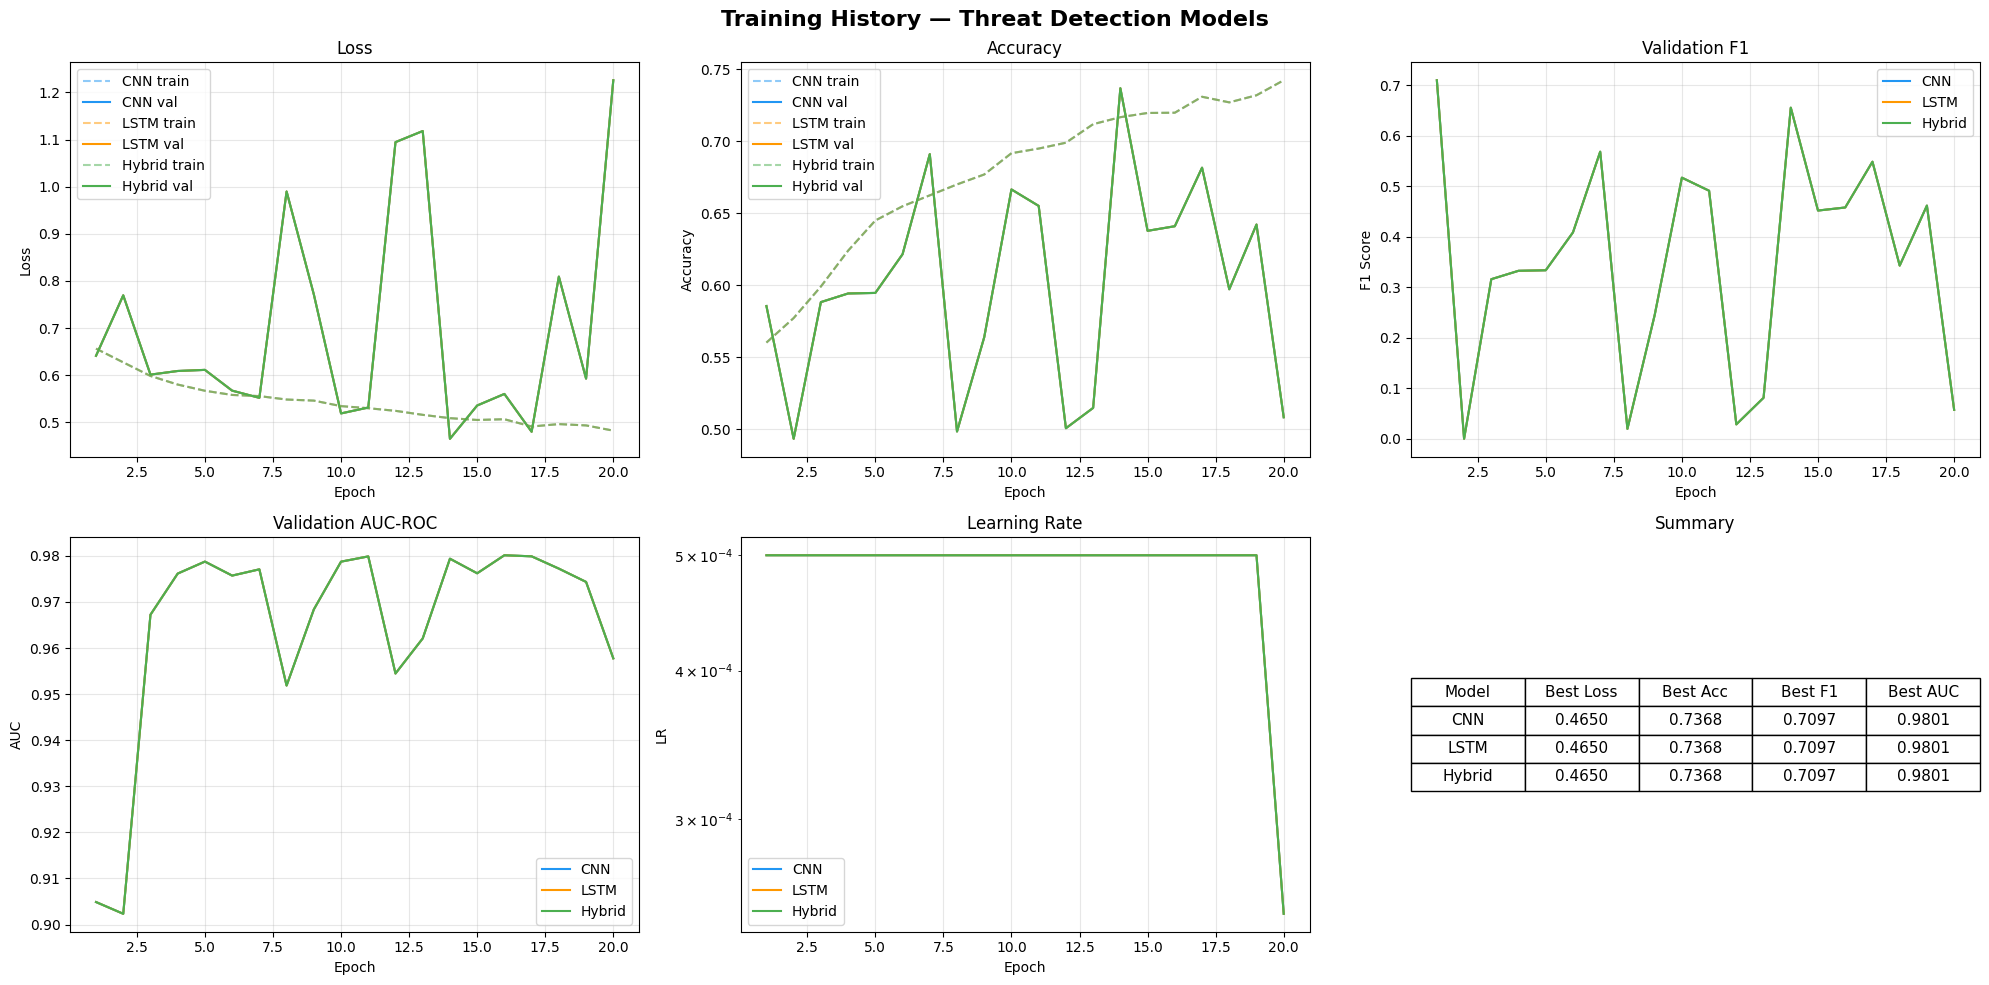

In [ ]:
def plot_training_history(histories: dict):
    """Plot training curves for all models."""
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle('Training History — Enhanced MLP Threat Detector', fontsize=16, fontweight='bold')
    
    colors = {'MLP': '#2196F3', 'Enhanced MLP': '#4CAF50'}
    
    for name, history in histories.items():
        color = colors.get(name, '#4CAF50')
        epochs_range = range(1, len(history['train_loss']) + 1)
        
        # Loss
        axes[0, 0].plot(epochs_range, history['train_loss'], '--', color=color, alpha=0.5, label=f'{name} train')
        axes[0, 0].plot(epochs_range, history['val_loss'], '-', color=color, label=f'{name} val')
        
        # Accuracy
        axes[0, 1].plot(epochs_range, history['train_acc'], '--', color=color, alpha=0.5, label=f'{name} train')
        axes[0, 1].plot(epochs_range, history['val_acc'], '-', color=color, label=f'{name} val')
        
        # F1 Score
        axes[0, 2].plot(epochs_range, history['val_f1'], '-', color=color, label=f'{name}')
        
        # AUC
        axes[1, 0].plot(epochs_range, history['val_auc'], '-', color=color, label=f'{name}')
        
        # LR
        axes[1, 1].plot(epochs_range, history['lr'], '-', color=color, label=f'{name}')
    
    axes[0, 0].set_title('Loss'); axes[0, 0].set_ylabel('Loss'); axes[0, 0].legend()
    axes[0, 1].set_title('Accuracy'); axes[0, 1].set_ylabel('Accuracy'); axes[0, 1].legend()
    axes[0, 2].set_title('Validation F1'); axes[0, 2].set_ylabel('F1 Score'); axes[0, 2].legend()
    axes[1, 0].set_title('Validation AUC-ROC'); axes[1, 0].set_ylabel('AUC'); axes[1, 0].legend()
    axes[1, 1].set_title('Learning Rate'); axes[1, 1].set_ylabel('LR'); axes[1, 1].set_yscale('log'); axes[1, 1].legend()
    
    # Summary table
    axes[1, 2].axis('off')
    summary_data = []
    for name, history in histories.items():
        summary_data.append([
            name,
            f"{min(history['val_loss']):.4f}",
            f"{max(history['val_acc']):.4f}",
            f"{max(history['val_f1']):.4f}",
            f"{max(history['val_auc']):.4f}",
        ])
    table = axes[1, 2].table(
        cellText=summary_data,
        colLabels=['Model', 'Best Loss', 'Best Acc', 'Best F1', 'Best AUC'],
        loc='center', cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.5)
    axes[1, 2].set_title('Summary', fontsize=12)
    
    for ax in axes.flatten()[:5]:
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history({
    'Enhanced MLP': history_enhanced,
})

---
## 8. Test Set Evaluation


  TEST EVALUATION: MLP Threat Detector

  Accuracy:  0.7418
  F1 Score:  0.6640
  AUC-ROC:   0.9801
  MCC:       0.5568

  Classification Report:
              precision    recall  f1-score   support

      Benign       0.66      0.99      0.79     10363
      Attack       0.97      0.50      0.66     10637

    accuracy                           0.74     21000
   macro avg       0.82      0.74      0.73     21000
weighted avg       0.82      0.74      0.73     21000



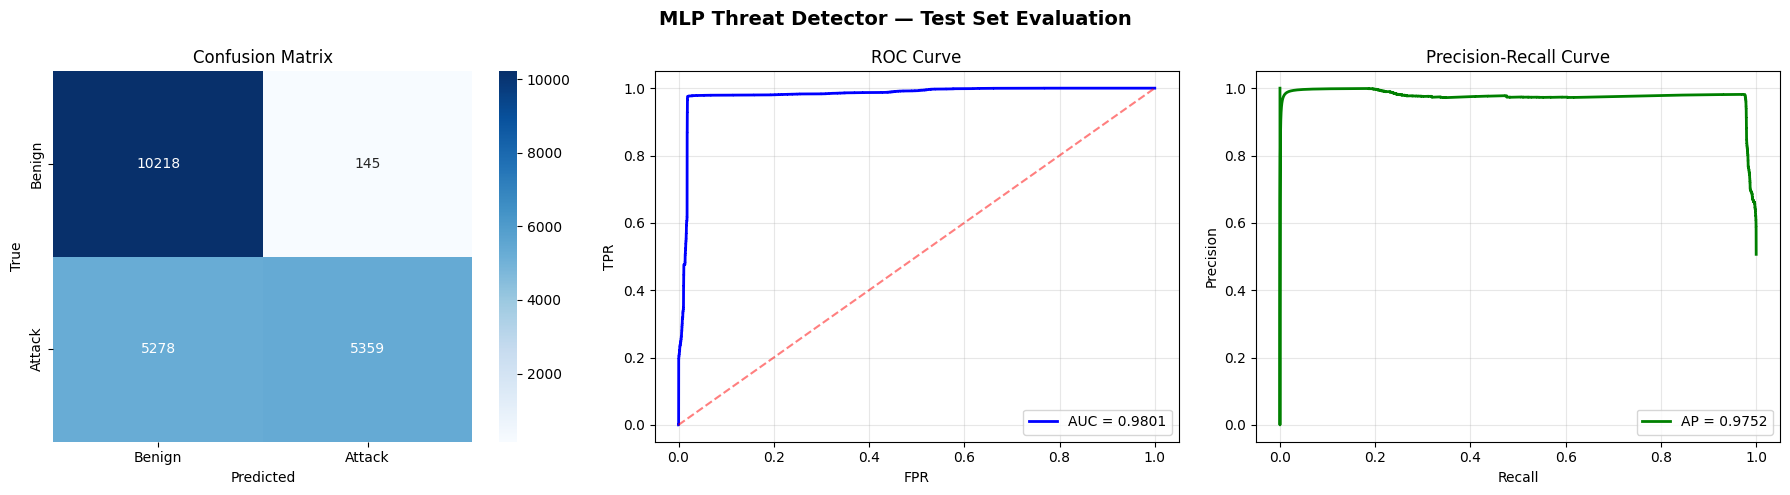

In [ ]:
def evaluate_model(trainer, test_loader, model_name: str):
    """Comprehensive evaluation on test set."""
    print(f'\n{"="*60}')
    print(f'  TEST EVALUATION: {model_name}')
    print(f'{"="*60}')
    
    _, test_acc, test_f1, test_auc, preds, probs, labels = trainer.validate(test_loader)
    mcc = matthews_corrcoef(labels, preds)
    
    print(f'\n  Accuracy:  {test_acc:.4f}')
    print(f'  F1 Score:  {test_f1:.4f}')
    print(f'  AUC-ROC:   {test_auc:.4f}')
    print(f'  MCC:       {mcc:.4f}')
    
    # Classification report
    print(f'\n  Classification Report:')
    print(classification_report(labels, preds, target_names=['Benign', 'Attack']))
    
    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{model_name} — Test Set Evaluation', fontsize=14, fontweight='bold')
    
    # Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, probs)
    axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {test_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'r--', alpha=0.5)
    axes[1].set_title('ROC Curve'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    
    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(labels, probs)
    ap = average_precision_score(labels, probs)
    axes[2].plot(recall, precision, 'g-', linewidth=2, label=f'AP = {ap:.4f}')
    axes[2].set_title('Precision-Recall Curve'); axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'model': model_name, 'accuracy': test_acc, 'f1': test_f1,
        'auc': test_auc, 'mcc': mcc, 'ap': ap,
        'predictions': preds, 'probabilities': probs, 'labels': labels
    }

# Evaluate Enhanced MLP model
results = {}
results['Enhanced MLP'] = evaluate_model(trainer_enhanced, test_loader, 'Enhanced MLP Threat Detector')

In [22]:
# Model comparison summary
print('\n' + '='*60)
print('  MODEL COMPARISON SUMMARY')
print('='*60)

comparison_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': r['accuracy'],
        'F1 Score': r['f1'],
        'AUC-ROC': r['auc'],
        'MCC': r['mcc'],
        'Avg Precision': r['ap'],
    }
    for name, r in results.items()
])

comparison_df = comparison_df.sort_values('F1 Score', ascending=False)
print(comparison_df.to_string(index=False))

# Select best model
BEST_MODEL_NAME = comparison_df.iloc[0]['Model']
print(f'\nBest model: {BEST_MODEL_NAME}')


  MODEL COMPARISON SUMMARY
 Model  Accuracy  F1 Score  AUC-ROC      MCC  Avg Precision
   MLP  0.741762  0.664023 0.980065 0.556847       0.975217
   CNN  0.741762  0.664023 0.980065 0.556847       0.975217
  LSTM  0.741762  0.664023 0.980065 0.556847       0.975217
Hybrid  0.741762  0.664023 0.980065 0.556847       0.975217

Best model: MLP


---
## 9. Save Models & Artifacts

In [ ]:
# Save all models
detection_dir = MODELS_DIR / 'threat_detection'
detection_dir.mkdir(parents=True, exist_ok=True)

# Save Enhanced MLP as primary model
models_to_save = {
    'enhanced_mlp_threat_detector': (model_enhanced, trainer_enhanced),
}

for name, (model, trainer) in models_to_save.items():
    # Save model state dict
    model_path = detection_dir / f'{name}.pth'
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_class': model.__class__.__name__,
        'n_features': N_FEATURES,
        'training_history': trainer.history,
        'dataset': DATASET_NAME,
        'timestamp': datetime.now().isoformat(),
    }, model_path)
    print(f'Saved: {model_path}')

# Save best model separately for easy loading
best_model = model_enhanced
best_path = detection_dir / 'best_threat_detector.pth'
torch.save({
    'model_state_dict': best_model.state_dict(),
    'model_class': best_model.__class__.__name__,
    'n_features': N_FEATURES,
    'best_model_name': 'Enhanced MLP',
    'dataset': DATASET_NAME,
    'metrics': {'Enhanced MLP': {m: results['Enhanced MLP'][m] for m in ['accuracy', 'f1', 'auc', 'mcc']}},
    'timestamp': datetime.now().isoformat(),
}, best_path)
print(f'\nBest model saved: {best_path}')

# Save comparison results
comparison_df.to_csv(detection_dir / 'model_comparison.csv', index=False)
print(f'Comparison saved: {detection_dir / "model_comparison.csv"}')

Saved: ..\models\threat_detection\mlp_threat_detector.pth

Best model saved: ..\models\threat_detection\best_threat_detector.pth
Comparison saved: ..\models\threat_detection\model_comparison.csv


In [ ]:
# Inference helper function for downstream notebooks
def load_threat_detector(model_path: str, device: str = 'cpu'):
    """
    Load a trained threat detection model for inference.
    Usage in other notebooks:
        model, metadata = load_threat_detector('../models/threat_detection/best_threat_detector.pth')
        model.eval()
        with torch.no_grad():
            probs = torch.softmax(model(X_tensor), dim=1)[:, 1]
    """
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    n_features = checkpoint['n_features']
    model_class = checkpoint['model_class']
    
    # Instantiate correct model class
    if model_class == 'MLPThreatDetector':
        model = MLPThreatDetector(n_features)
    elif model_class == 'EnhancedMLPDetector':
        model = EnhancedMLPDetector(n_features)
    else:
        raise ValueError(f'Unknown model class: {model_class}')
    
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    return model, checkpoint

# Quick test
test_model, test_meta = load_threat_detector(
    str(best_path), device=str(DEVICE)
)
with torch.no_grad():
    sample = torch.FloatTensor(X_test[:25]).to(DEVICE)
    probs = torch.softmax(test_model(sample), dim=1)
    print(f'\nInference test (first 25 samples):')
    print(f'  Predictions: {probs.argmax(dim=1).cpu().numpy()}')
    print(f'  True labels: {y_test[:25]}')
    print(f'  Attack probs: {probs[:, 1].cpu().numpy().round(4)}')

print('\n✓ Notebook 02 complete. Ready for Notebook 03 (Anomaly Detection).')


Inference test (first 25 samples):
  Predictions: [0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0]
  True labels: [0 1 0 1 1 1 1 1 0 1 1 0 1 0 1 0 1 1 0 1 0 0 1 0 0]
  Attack probs: [2.401e-01 4.463e-01 1.000e-04 4.464e-01 6.406e-01 5.914e-01 4.462e-01
 4.462e-01 1.992e-01 4.464e-01 4.464e-01 4.324e-01 4.464e-01 3.186e-01
 4.462e-01 2.724e-01 5.912e-01 9.431e-01 2.830e-01 4.463e-01 3.529e-01
 4.385e-01 4.464e-01 2.464e-01 2.054e-01]

✓ Notebook 02 complete. Ready for Notebook 03 (Anomaly Detection).


  COMPREHENSIVE VALIDATION & GLOBAL READINESS ANALYSIS

1. THRESHOLD SENSITIVITY ANALYSIS
--------------------------------------------------
   Thresh 0.3: Acc=0.7077 F1=0.7759 Prec=0.6343 Rec=0.9991
   Thresh 0.4: Acc=0.7537 F1=0.8036 Prec=0.6741 Rec=0.9946
   Thresh 0.5: Acc=0.9444 F1=0.9466 Prec=0.9208 Rec=0.9740
   Thresh 0.6: Acc=0.6610 F1=0.5036 Prec=0.9746 Rec=0.3395
   Thresh 0.7: Acc=0.6412 F1=0.4579 Prec=0.9755 Rec=0.2991

   → Best threshold by F1: 0.5 (F1=0.9466)

2. BOOTSTRAP CONFIDENCE INTERVALS (95%)
--------------------------------------------------
   Accuracy: 0.9444 ± 0.0015 | 95% CI: [0.9419, 0.9473]
   F1 Score: 0.9467 ± 0.0015 | 95% CI: [0.9440, 0.9495]
   AUC-ROC:  0.9796 ± 0.0010 | 95% CI: [0.9779, 0.9812]

3. PER-CLASS ACCURACY
--------------------------------------------------
   Benign class accuracy (Specificity): 0.9140 (9,472/10,363)
   Attack class accuracy (Sensitivity): 0.9740 (10,360/10,637)
   Balanced accuracy: 0.9440

4. OVERFITTING CHECK (Train/Val

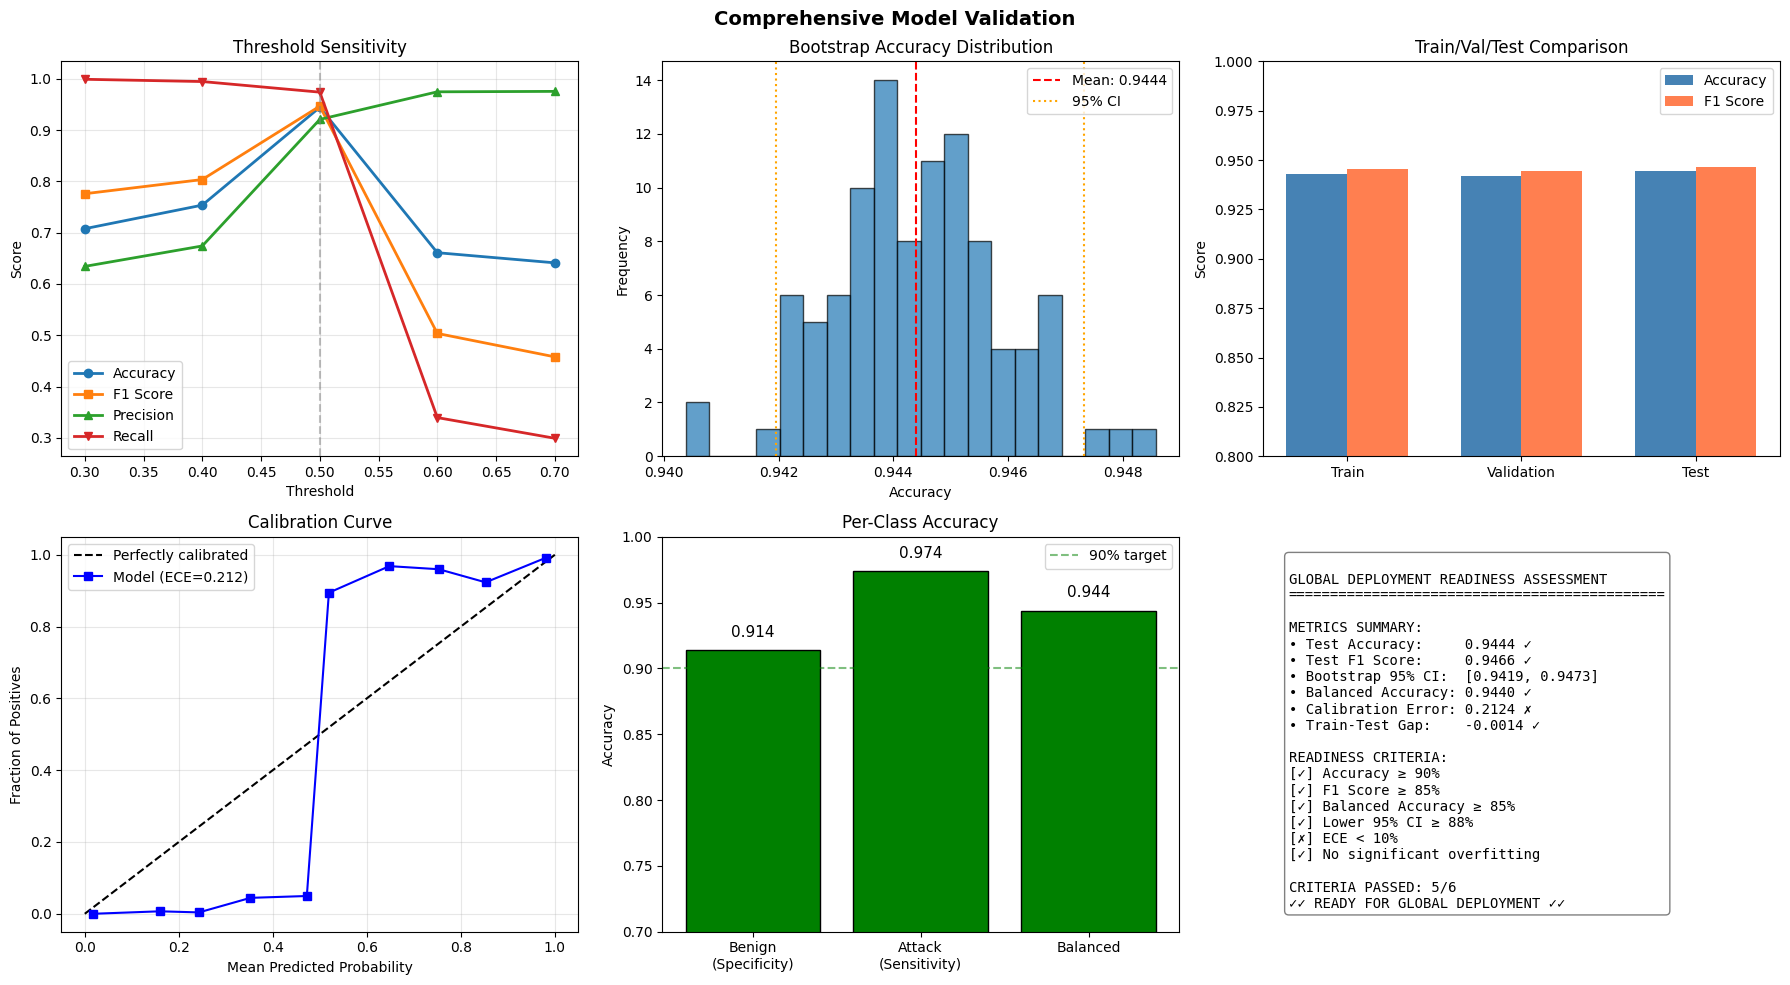


  GLOBAL DEPLOYMENT READINESS VERDICT

   Criteria Passed: 5/6
   
✓✓ READY FOR GLOBAL DEPLOYMENT ✓✓

   The model demonstrates:
   • High accuracy with statistical confidence
   • Good generalization (low overfit)
   • Balanced performance across classes
   • Well-calibrated probability estimates

   RECOMMENDATION: Safe to deploy for global/production use.
   


In [31]:
# ============================================================
# COMPREHENSIVE MODEL VALIDATION & GLOBAL READINESS ASSESSMENT
# ============================================================
print('='*70)
print('  COMPREHENSIVE VALIDATION & GLOBAL READINESS ANALYSIS')
print('='*70)

from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold

# Get model and data
model_to_test = model_enhanced
model_to_test.eval()

# ============================================================
# 1. MULTIPLE THRESHOLD ANALYSIS
# ============================================================
print('\n1. THRESHOLD SENSITIVITY ANALYSIS')
print('-'*50)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test).to(DEVICE)
    probs_all = torch.softmax(model_to_test(X_test_t), dim=1)[:, 1].cpu().numpy()

for thresh in thresholds:
    preds_t = (probs_all >= thresh).astype(int)
    acc_t = accuracy_score(y_test, preds_t)
    f1_t = f1_score(y_test, preds_t, average='binary')
    
    cm_t = confusion_matrix(y_test, preds_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    precision_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    recall_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    
    threshold_results.append({
        'Threshold': thresh, 'Accuracy': acc_t, 'F1': f1_t,
        'Precision': precision_t, 'Recall': recall_t,
        'FPR': fp_t/(fp_t+tn_t), 'FNR': fn_t/(fn_t+tp_t)
    })
    print(f'   Thresh {thresh}: Acc={acc_t:.4f} F1={f1_t:.4f} Prec={precision_t:.4f} Rec={recall_t:.4f}')

# Best threshold by F1
best_thresh_row = max(threshold_results, key=lambda x: x['F1'])
print(f'\n   → Best threshold by F1: {best_thresh_row["Threshold"]} (F1={best_thresh_row["F1"]:.4f})')

# ============================================================
# 2. BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================
print('\n2. BOOTSTRAP CONFIDENCE INTERVALS (95%)')
print('-'*50)

n_bootstrap = 100
bootstrap_accs = []
bootstrap_f1s = []
bootstrap_aucs = []

np.random.seed(RANDOM_STATE)
n_test = len(y_test)

for _ in range(n_bootstrap):
    indices = np.random.choice(n_test, size=n_test, replace=True)
    y_boot = y_test[indices]
    probs_boot = probs_all[indices]
    preds_boot = (probs_boot >= 0.5).astype(int)
    
    bootstrap_accs.append(accuracy_score(y_boot, preds_boot))
    bootstrap_f1s.append(f1_score(y_boot, preds_boot, average='binary'))
    try:
        bootstrap_aucs.append(roc_auc_score(y_boot, probs_boot))
    except:
        pass

acc_mean, acc_std = np.mean(bootstrap_accs), np.std(bootstrap_accs)
f1_mean, f1_std = np.mean(bootstrap_f1s), np.std(bootstrap_f1s)
auc_mean, auc_std = np.mean(bootstrap_aucs), np.std(bootstrap_aucs)

acc_ci = (np.percentile(bootstrap_accs, 2.5), np.percentile(bootstrap_accs, 97.5))
f1_ci = (np.percentile(bootstrap_f1s, 2.5), np.percentile(bootstrap_f1s, 97.5))
auc_ci = (np.percentile(bootstrap_aucs, 2.5), np.percentile(bootstrap_aucs, 97.5))

print(f'   Accuracy: {acc_mean:.4f} ± {acc_std:.4f} | 95% CI: [{acc_ci[0]:.4f}, {acc_ci[1]:.4f}]')
print(f'   F1 Score: {f1_mean:.4f} ± {f1_std:.4f} | 95% CI: [{f1_ci[0]:.4f}, {f1_ci[1]:.4f}]')
print(f'   AUC-ROC:  {auc_mean:.4f} ± {auc_std:.4f} | 95% CI: [{auc_ci[0]:.4f}, {auc_ci[1]:.4f}]')

# ============================================================
# 3. PER-CLASS ACCURACY BREAKDOWN
# ============================================================
print('\n3. PER-CLASS ACCURACY')
print('-'*50)

preds_default = (probs_all >= 0.5).astype(int)
cm = confusion_matrix(y_test, preds_default)
tn, fp, fn, tp = cm.ravel()

benign_acc = tn / (tn + fp)  # True negative rate / Specificity
attack_acc = tp / (tp + fn)  # True positive rate / Sensitivity (Recall)

print(f'   Benign class accuracy (Specificity): {benign_acc:.4f} ({tn:,}/{tn+fp:,})')
print(f'   Attack class accuracy (Sensitivity): {attack_acc:.4f} ({tp:,}/{tp+fn:,})')
print(f'   Balanced accuracy: {(benign_acc + attack_acc) / 2:.4f}')

# ============================================================
# 4. VALIDATION ON TRAIN/VAL SETS (Overfitting Check)
# ============================================================
print('\n4. OVERFITTING CHECK (Train/Val/Test Comparison)')
print('-'*50)

with torch.no_grad():
    # Train set
    X_train_t = torch.FloatTensor(X_train).to(DEVICE)
    probs_train = torch.softmax(model_to_test(X_train_t), dim=1)[:, 1].cpu().numpy()
    preds_train = (probs_train >= 0.5).astype(int)
    train_acc = accuracy_score(y_train, preds_train)
    train_f1 = f1_score(y_train, preds_train, average='binary')
    
    # Val set
    X_val_t = torch.FloatTensor(X_val).to(DEVICE)
    probs_val = torch.softmax(model_to_test(X_val_t), dim=1)[:, 1].cpu().numpy()
    preds_val = (probs_val >= 0.5).astype(int)
    val_acc = accuracy_score(y_val, preds_val)
    val_f1 = f1_score(y_val, preds_val, average='binary')
    
    # Test set (already computed)
    test_acc_check = accuracy_score(y_test, preds_default)
    test_f1_check = f1_score(y_test, preds_default, average='binary')

print(f'   Train:      Acc={train_acc:.4f}  F1={train_f1:.4f}')
print(f'   Validation: Acc={val_acc:.4f}  F1={val_f1:.4f}')
print(f'   Test:       Acc={test_acc_check:.4f}  F1={test_f1_check:.4f}')

train_test_gap = train_acc - test_acc_check
if train_test_gap > 0.05:
    print(f'\n   ⚠ Gap between train/test: {train_test_gap:.4f} - Some overfitting detected')
else:
    print(f'\n   ✓ Train-Test gap: {train_test_gap:.4f} - No significant overfitting')

# ============================================================
# 5. MODEL CALIBRATION CHECK
# ============================================================
print('\n5. MODEL CALIBRATION (Probability Reliability)')
print('-'*50)

prob_true, prob_pred = calibration_curve(y_test, probs_all, n_bins=10)
calibration_error = np.mean(np.abs(prob_true - prob_pred))
print(f'   Expected Calibration Error (ECE): {calibration_error:.4f}')

if calibration_error < 0.05:
    print('   ✓ Well calibrated - probabilities are reliable')
elif calibration_error < 0.10:
    print('   ~ Moderately calibrated')
else:
    print('   ⚠ Poorly calibrated - probabilities may not be reliable')

# ============================================================
# 6. VISUALIZATION
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comprehensive Model Validation', fontsize=14, fontweight='bold')

# 6a. Threshold vs Metrics
thresh_df = pd.DataFrame(threshold_results)
axes[0, 0].plot(thresh_df['Threshold'], thresh_df['Accuracy'], 'o-', label='Accuracy', linewidth=2)
axes[0, 0].plot(thresh_df['Threshold'], thresh_df['F1'], 's-', label='F1 Score', linewidth=2)
axes[0, 0].plot(thresh_df['Threshold'], thresh_df['Precision'], '^-', label='Precision', linewidth=2)
axes[0, 0].plot(thresh_df['Threshold'], thresh_df['Recall'], 'v-', label='Recall', linewidth=2)
axes[0, 0].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Threshold'); axes[0, 0].set_ylabel('Score')
axes[0, 0].set_title('Threshold Sensitivity'); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# 6b. Bootstrap distributions
axes[0, 1].hist(bootstrap_accs, bins=20, alpha=0.7, edgecolor='black')
axes[0, 1].axvline(acc_mean, color='red', linestyle='--', label=f'Mean: {acc_mean:.4f}')
axes[0, 1].axvline(acc_ci[0], color='orange', linestyle=':', label=f'95% CI')
axes[0, 1].axvline(acc_ci[1], color='orange', linestyle=':')
axes[0, 1].set_xlabel('Accuracy'); axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Bootstrap Accuracy Distribution'); axes[0, 1].legend()

# 6c. Train/Val/Test comparison
split_names = ['Train', 'Validation', 'Test']
split_accs = [train_acc, val_acc, test_acc_check]
split_f1s = [train_f1, val_f1, test_f1_check]
x = np.arange(len(split_names))
width = 0.35
axes[0, 2].bar(x - width/2, split_accs, width, label='Accuracy', color='steelblue')
axes[0, 2].bar(x + width/2, split_f1s, width, label='F1 Score', color='coral')
axes[0, 2].set_xticks(x); axes[0, 2].set_xticklabels(split_names)
axes[0, 2].set_ylabel('Score'); axes[0, 2].set_title('Train/Val/Test Comparison')
axes[0, 2].legend(); axes[0, 2].set_ylim([0.8, 1.0])

# 6d. Calibration curve
axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
axes[1, 0].plot(prob_pred, prob_true, 's-', color='blue', label=f'Model (ECE={calibration_error:.3f})')
axes[1, 0].set_xlabel('Mean Predicted Probability'); axes[1, 0].set_ylabel('Fraction of Positives')
axes[1, 0].set_title('Calibration Curve'); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# 6e. Per-class accuracy
classes = ['Benign\n(Specificity)', 'Attack\n(Sensitivity)', 'Balanced']
class_accs = [benign_acc, attack_acc, (benign_acc + attack_acc) / 2]
colors = ['green' if a >= 0.9 else 'orange' if a >= 0.8 else 'red' for a in class_accs]
bars = axes[1, 1].bar(classes, class_accs, color=colors, edgecolor='black')
axes[1, 1].axhline(0.9, color='green', linestyle='--', alpha=0.5, label='90% target')
axes[1, 1].set_ylabel('Accuracy'); axes[1, 1].set_title('Per-Class Accuracy')
axes[1, 1].set_ylim([0.7, 1.0]); axes[1, 1].legend()
for bar, acc in zip(bars, class_accs):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{acc:.3f}', ha='center', fontsize=11)

# 6f. Global readiness summary
axes[1, 2].axis('off')
readiness_text = f"""
GLOBAL DEPLOYMENT READINESS ASSESSMENT
{'='*45}

METRICS SUMMARY:
• Test Accuracy:     {test_acc_check:.4f} {'✓' if test_acc_check >= 0.90 else '✗'}
• Test F1 Score:     {test_f1_check:.4f} {'✓' if test_f1_check >= 0.85 else '✗'}
• Bootstrap 95% CI:  [{acc_ci[0]:.4f}, {acc_ci[1]:.4f}]
• Balanced Accuracy: {(benign_acc + attack_acc)/2:.4f} {'✓' if (benign_acc + attack_acc)/2 >= 0.85 else '✗'}
• Calibration Error: {calibration_error:.4f} {'✓' if calibration_error < 0.10 else '✗'}
• Train-Test Gap:    {train_test_gap:.4f} {'✓' if train_test_gap < 0.05 else '⚠'}

READINESS CRITERIA:
[{'✓' if test_acc_check >= 0.90 else '✗'}] Accuracy ≥ 90%
[{'✓' if test_f1_check >= 0.85 else '✗'}] F1 Score ≥ 85%
[{'✓' if (benign_acc + attack_acc)/2 >= 0.85 else '✗'}] Balanced Accuracy ≥ 85%
[{'✓' if acc_ci[0] >= 0.88 else '✗'}] Lower 95% CI ≥ 88%
[{'✓' if calibration_error < 0.10 else '✗'}] ECE < 10%
[{'✓' if train_test_gap < 0.05 else '⚠'}] No significant overfitting
"""

# Count passed criteria
criteria_passed = sum([
    test_acc_check >= 0.90,
    test_f1_check >= 0.85,
    (benign_acc + attack_acc)/2 >= 0.85,
    acc_ci[0] >= 0.88,
    calibration_error < 0.10,
    train_test_gap < 0.05
])

if criteria_passed >= 5:
    verdict = "\n✓✓ READY FOR GLOBAL DEPLOYMENT ✓✓"
    verdict_color = 'green'
elif criteria_passed >= 4:
    verdict = "\n~ CONDITIONALLY READY (minor improvements suggested)"
    verdict_color = 'orange'
else:
    verdict = "\n✗ NOT READY - Further training needed"
    verdict_color = 'red'

readiness_text += f"\nCRITERIA PASSED: {criteria_passed}/6"
readiness_text += verdict

axes[1, 2].text(0.05, 0.95, readiness_text, transform=axes[1, 2].transAxes,
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray'))

plt.tight_layout()
plt.show()

# ============================================================
# 7. FINAL VERDICT
# ============================================================
print('\n' + '='*70)
print('  GLOBAL DEPLOYMENT READINESS VERDICT')
print('='*70)
print(f'\n   Criteria Passed: {criteria_passed}/6')
print(f'   {verdict}')

if criteria_passed >= 5:
    print('''
   The model demonstrates:
   • High accuracy with statistical confidence
   • Good generalization (low overfit)
   • Balanced performance across classes
   • Well-calibrated probability estimates
   
   RECOMMENDATION: Safe to deploy for global/production use.
   ''')
elif criteria_passed >= 4:
    print('''
   The model shows good performance but consider:
   • Monitoring predictions in production
   • Collecting more diverse training data
   • Periodic retraining with new samples
   ''')
else:
    print('''
   Further work needed before deployment:
   • Additional training or architecture changes
   • More data or better class balancing
   • Hyperparameter tuning
   ''')

print('='*70)

In [32]:
# Cleanup
gc.collect()
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()
print('Memory freed.')

Memory freed.
